<a href="https://colab.research.google.com/github/pachterlab/LSRRSRLFKOTWMWMP_2024/blob/main/lr_kallisto_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###lr-kallisto Example single-cell notebook for processing ONT single-nuclei data, starting with seqspec and using splitcode for extraction

#Introduction: Pseudoalignment of single-cell long read RNA seq data

References:
[1] Loving, R, Sullivan, DK, Reese, F, Rebboah, E, Sakr, J, Rezaie, N, Liang, HY, Filimban, G, Kawauchi, S, Oakes, C, Trout, D, Williams, BA, MacGregor, G, Wold, BJ, Mortazavi, A, Pachter, L Long-read sequencing transcriptome quantification with lr-kallisto. bioRxiv 2024.07.19.604364 https://doi.org/10.1101/2024.07.19.604364

[2] Sullivan DK, Pachter L. (2024). Flexible parsing, interpretation, and editing of technical sequences with splitcode. Bioinformatics. https://doi.org/10.1093/bioinformatics/btae331

[3] Ali Sina Booeshaghi, Xi Chen, Lior Pachter, A machine-readable specification for genomics assays, Bioinformatics, Volume 40, Issue 4, April 2024, btae168.

kallisto can perform long-read pseudoalignment of nucleotide sequences against a large k-mer reference while retaining single-cell (for single-cell RNA sequencing data) or sample (for bulk RNA seq data) resolution. To perform long-read pseudoalignment, first add -k 63 to kb ref and, second, add the --long flag to the kb count commands.

Long-read pseudoalignment is performed by the longer k-mer length improving the quality of mapping k-mers in the higher sequencing error rates (relative to short read sequencing), making it more probable that the read originates from the transcript compatibility class it maps to. As k increases, the number of distinct k-mers also increases, but the number of contigs decreases. This implies that the number of transcripts in a transcript compatibility class decreases on average with increasing length of k. Overall, the complexity of the T-DBG decreases (Supplementary Fig. 5), increasing the probability of the read originating from the transcript compatibility class it is mapping to. Furthermore, this also increases the probability of the intersection of equivalence classes being nonempty, which increases the overall mapping rate.

The workflow can be executed in a few lines of code, and computational requirements do not exceed those of a standard laptop. Building on kallisto’s versatility, the workflow is compatible with all state-of-the-art single-cell and bulk RNA sequencing methods, including but not limited to SMART-Seq [add citation]_ and SPLiT-Seq [add citation]_ (including Parse Biosciences) and performance is state-of-the-art on both PacBio and Oxford Nanopore Technologies long-read data.

Note: For long-read single-cell data to be processed with lr-kallisto some preprocessing steps are required. Here we present the use of splitcode [2] and seqspec [3] to facilitate an automated processing of LR-SPLiT-Seq. seqspec is used to create a configuration file for splitcode to extract barcodes, umis, and the biological sequences from the reads [2][3]. seqspec requires as input a machine readable specification file for the sample protocol that is in the seqspec format. splitcode can then be called on the reads with the configuration file created by seqspec to extract from the reads the barcodes, umis, and biological sequences. The output of splitcode can be piped directly into lr-kallisto or output to files that are processed with lr-kallisto.

The long-read pseudoalignment workflows can be used to align RNA sequencing data to any transcriptome reference

Downloading splitcode (v0.30.0) source code from github

Installing splitcode from source

In [ ]:
!git clone https://github.com/pachterlab/splitcode
!cd splitcode; mkdir build; cd build; cmake ..; make

Cloning into 'splitcode'...
remote: Enumerating objects: 2833, done.
remote: Counting objects: 100% (230/230), done.
remote: Compressing objects: 100% (117/117), done.
remote: Total 2833 (delta 132), reused 197 (delta 111), pack-reused 2603 (from 1)
Receiving objects: 100% (2833/2833), 15.76 MiB | 10.25 MiB/s, done.
Resolving deltas: 100% (1557/1557), done.
CMake Deprecation Warning at CMakeLists.txt:1 (cmake_minimum_required):
  Compatibility with CMake < 3.5 will be removed from a future version of
  CMake.

  Update the VERSION argument <min> value or use a ...<max> suffix to tell
  CMake that the project does not need compatibility with older versions.


-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- 

Show splitcode version

In [ ]:
#show splitcode version
!splitcode/build/src/splitcode --version

splitcode, version 0.30.0


#For this notebook we use a subset of 2 million reads of the exome capture cortex data discussed in Fig1 of [1]. We now download the example data and seqspec for the data with supporting files, such as on-lists for correcting barcodes and configuration files to use with splitcode to do SPLiT-seq specific correction and merging of barcodes with different priming strategies for the same cell.

In [ ]:
#Get example data and seqspec with supporting on-list files and configs for barcode correction and merging that is SPLiT-Seq specific
!wget https://zenodo.org/records/14146317/files/lr-kallisto_example.tar.gz

--2024-12-02 03:45:23--  https://zenodo.org/records/14146317/files/lr-kallisto_example.tar.gz
Resolving zenodo.org (zenodo.org)... 188.185.45.92, 188.185.48.194, 188.185.43.25, ...
Connecting to zenodo.org (zenodo.org)|188.185.45.92|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 970627147 (926M) [application/octet-stream]
Saving to: ‘lr-kallisto_example.tar.gz’

lr-kallisto_example 100%[===================>] 925.66M  28.2MB/s    in 36s     

2024-12-02 03:46:00 (25.8 MB/s) - ‘lr-kallisto_example.tar.gz’ saved [970627147/970627147]



Next we uncompress the example data folder to access the contents and copy the files to the working directory.

In [ ]:
#uncompress folder
!tar -xvf lr-kallisto_example.tar.gz
!cp lr-kallisto_example/r*txt .

lr-kallisto_example/
lr-kallisto_example/spec.yaml
lr-kallisto_example/13G-gc_5W.fastq.gz
lr-kallisto_example/config.mergeRT
lr-kallisto_example/r2_3.txt
lr-kallisto_example/config_RT_randO.txt
lr-kallisto_example/config-correct.txt
lr-kallisto_example/config_RT_polyT.txt
lr-kallisto_example/r1_R.txt
lr-kallisto_example/r1_T.txt
lr-kallisto_example/13G_2M.fastq.gz


We now install seqspec using pip to install seqspec from github and use `seqspec index` command to create the splitcode config for demultiplexing the reads with splitcode.

In [ ]:
#Install seqspec
!pip install git+https://github.com/pachterlab/seqspec

!seqspec index -m rna -s file -t splitcode lr-kallisto_example/spec.yaml > ONT.config

  Cloning https://github.com/pachterlab/seqspec to /tmp/pip-req-build-y5u1g6so
  Running command git clone --filter=blob:none --quiet https://github.com/pachterlab/seqspec /tmp/pip-req-build-y5u1g6so
  Resolved https://github.com/pachterlab/seqspec to commit 1475ff00eac673af900d9be4fb36f23716058da4
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.4 MB/s eta 0:00:00
  Created wheel for seqspec: filename=seqspec-0.3.1-py3-none-any.whl size=47739 sha256=72dbaac76ab3efc29fb99c6a9ffd12bd3d5edaaf5b7fe8d5c4854d83ebb9dfbd
  Stored in directory: /tmp/pip-ephem-wheel-cache-ufx9wed9/wheels/a3/4d/76/1e56215ad56c936bb0c24c4be01c5e8f7aeb0af528d415423c
Successfully built seqspec


Next we use sed to change the error tolerance to only allow 1 error for runtime considerations in Google Colab; in practice, we have found the tolerance of 3 errors to be a good choice for SPLiT-Seq ONT R10.4 data.

In [ ]:
#Make config less error tolerant, allowing one error instead of 3 errors
!sed -i 's/3:3:3/1:1:1/g' ONT.config;

We can now use splitcode to extract barcodes, cDNAs, and umis for the single-nuclei ONT data

In [ ]:
#extract barcodes, cDNAs, and umis
!splitcode/build/src/splitcode -c ONT.config -t 2 lr-kallisto_example/13G_2M.fastq.gz -o igvfb01_13G_scmodified/igvfb01_13G_5W.fastq.gz

* Forcing --gzip because all output file names end in .gz
* Using a list of 8 tags (vector size: 8; map size: 6,286; num elements in map: 6,344)
* will process sample 1: lr-kallisto_example/13G_2M.fastq.gz
* processing the reads ...
done 
* processed 1,000,000 reads


We now reorient the reads as they are extracted in forward, complement, reverse, and reverse complement orientations and merge the results.  

In [ ]:
import os

samples = [''] #,'13G']


for sample in samples:
    files_f = [sample+'f', sample+'c']
    files_r = [sample+'r', sample+'rc']

    for f in files_r+files_f:
        for fastq in ["barcode", "cDNA", "umi"]:
            os.system("gunzip -f "+f+"_"+fastq+".fastq.gz")

    c = 0
    writelines = ""
    fastqc=open(sample+'c_barcode.fastq', 'r')
    ofastqc=open(sample+'c_barcode.tmp.fastq', 'w+')
    for l in fastqc.readlines():
        c+=1
        if l.startswith("@") or l.startswith("+"):
            writelines+=l
        elif l != "\n":
            writelines+=l[0:8][::-1]+l[8:16][::-1]+l[16:24][::-1]+"\n"
        else:
            writelines+=l
        if c == 4:
            ofastqc.write(writelines)
            c = 0
            writelines = ""
    fastqc.close()
    ofastqc.close()
    os.system("mv "+sample+'c_barcode.tmp.fastq '+sample+'c_barcode.fastq')

    fastqc=open(sample+'r_barcode.fastq', 'r')
    ofastqc=open(sample+'r_barcode.tmp.fastq', 'w+')
    for l in fastqc.readlines():
        c+=1
        if l.startswith("@") or l.startswith("+"):
            writelines+=l
        elif l != "\n":
            writelines+=l[::-1]+"\n"
        else:
            writelines+=l
        if c == 4:
            ofastqc.write(writelines)
            c = 0
            writelines = ""
    fastqc.close()
    ofastqc.close()
    os.system("mv "+sample+'r_barcode.tmp.fastq '+sample+'r_barcode.fastq')

    c = 0
    writelines = ""
    fastqc=open(sample+'rc_barcode.fastq', 'r')
    ofastqc=open(sample+'rc_barcode.tmp.fastq', 'w+')
    for l in fastqc.readlines():
        c+=1
        if l.startswith("@") or l.startswith("+"):
            writelines+=l
        elif l != "\n":
            writelines+=l[16:24]+l[8:16]+l[0:8]+"\n"
        else:
            writelines+=l
        if c == 4:
            ofastqc.write(writelines)
            c = 0
            writelines = ""
    fastqc.close()
    ofastqc.close()
    os.system("mv "+sample+'rc_barcode.tmp.fastq '+sample+'rc_barcode.fastq')


    for fastq in ["barcode", "cDNA", "umi"]:
        cmd = "cat "
        for f in files_f+files_r:
            cmd += f+'_'+fastq+'.fastq '
        cmd += '> '+sample+'_'+fastq+'.fastq'
        print(cmd)
        os.system(cmd)

cat f_barcode.fastq c_barcode.fastq r_barcode.fastq rc_barcode.fastq > _barcode.fastq
cat f_cDNA.fastq c_cDNA.fastq r_cDNA.fastq rc_cDNA.fastq > _cDNA.fastq
cat f_umi.fastq c_umi.fastq r_umi.fastq rc_umi.fastq > _umi.fastq


We now correct barcodes, and merge rand oligo primed and random hexamer primed together

In [ ]:
#correct barcodes
!splitcode/build/src/splitcode -c lr-kallisto_example/config-correct.txt --nFastqs=2 --select=0 --gzip -o 13G_cDNA.fastq.gz _cDNA.fastq _barcode.fastq -t 2;

!splitcode/build/src/splitcode -c lr-kallisto_example/config-correct.txt --nFastqs=2 --select=0 --gzip -o 13G_umi.fastq.gz _umi.fastq _barcode.fastq -t 2;

#merge randO and polyT
!splitcode/build/src/splitcode -c lr-kallisto_example/config.mergeRT -o 13G_barcode.fastq 13G_barcode.fastq.gz -t 2;

* Using a list of 384 tags (vector size: 384; map size: 32,059; num elements in map: 42,792)
* will process sample 1: _cDNA.fastq
                         _barcode.fastq
3M reads processed         
done 
* processed 4,000,000 reads
* Using a list of 384 tags (vector size: 384; map size: 32,059; num elements in map: 42,792)
* will process sample 1: _umi.fastq
                         _barcode.fastq
3M reads processed         
done 
* processed 4,000,000 reads
* Using a list of 96 tags (vector size: 96; map size: 2,989; num elements in map: 3,168)
* will process sample 1: 13G_barcode.fastq.gz
* processing the reads ...
done 
* processed 378,887 reads


We also correct and extract barcodes that are polyT primed only

In [ ]:
#correct barcodes and extract only polyT
!splitcode/build/src/splitcode -c lr-kallisto_example/config_RT_polyT.txt --nFastqs=2 --select=0 --gzip -o 13G_cDNA_polyT.fastq.gz 13G_cDNA.fastq.gz 13G_barcode.fastq.gz -t 2;

!splitcode/build/src/splitcode -c lr-kallisto_example/config_RT_polyT.txt --nFastqs=2 --select=0 --gzip -o 13G_umi_polyT.fastq.gz 13G_umi.fastq.gz 13G_barcode.fastq.gz -t 2;


* Using a list of 288 tags (vector size: 288; map size: 22,690; num elements in map: 31,560)
* will process sample 1: 13G_cDNA.fastq.gz
                         13G_barcode.fastq.gz
* processing the reads ...
done 
* processed 378,887 reads
* Using a list of 288 tags (vector size: 288; map size: 22,690; num elements in map: 31,560)
* will process sample 1: 13G_umi.fastq.gz
                         13G_barcode.fastq.gz
* processing the reads ...
done 
* processed 378,887 reads


Likewise, we correct and extract barcodes that are random oligo primed only

In [ ]:
#correct barcodes and extract only randO
!splitcode/build/src/splitcode -c lr-kallisto_example/config_RT_randO.txt --nFastqs=2 --select=0 --gzip -o 13G_cDNA_randO.fastq.gz 13G_cDNA.fastq.gz 13G_barcode.fastq.gz -t 2;

!splitcode/build/src/splitcode -c lr-kallisto_example/config_RT_randO.txt --nFastqs=2 --select=0 --gzip -o 13G_umi_randO.fastq.gz 13G_umi.fastq.gz 13G_barcode.fastq.gz -t 2;

#switch randO and polyT
!splitcode/build/src/splitcode -c lr-kallisto_example/config.mergeRT -o 13G_barcode_randO.fastq 13G_barcode_randO.fastq.gz -t 2;

* Using a list of 288 tags (vector size: 288; map size: 22,913; num elements in map: 31,647)
* will process sample 1: 13G_cDNA.fastq.gz
                         13G_barcode.fastq.gz
* processing the reads ...
done 
* processed 378,887 reads
* Using a list of 288 tags (vector size: 288; map size: 22,913; num elements in map: 31,647)
* will process sample 1: 13G_umi.fastq.gz
                         13G_barcode.fastq.gz
* processing the reads ...
done 
* processed 378,887 reads
* Using a list of 96 tags (vector size: 96; map size: 2,989; num elements in map: 3,168)
* will process sample 1: 13G_barcode_randO.fastq.gz
* processing the reads ...
done 
* processed 226,788 reads


We then install kb and gget using pip

In [ ]:
#install gget and kb
!pip install -q kb_python gget

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 41.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.0/22.0 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 

We now can either download references using `kb ref` or use `kb ref` and `gget ref` to download genome and annotation for a given species and build index and t2g from scratch.

In [ ]:
#download reference for mouse with k-mer size 31 or 63
!kb ref -k 31 -d mouse -i mouse_k-31.idx -g mouse.t2g
!kb ref -k 63 -d mouse -i mouse_k-63.idx -g mouse.t2g
#alternatively build your own
'''
!kb ref -k 63\
    -i mouse_k-63.idx \
    -g t2g.txt \
    -f1 fasta.fa \
    $(gget ref --ftp -w dna,gtf mouse)
'''

[2024-12-04 18:08:15,925]    INFO [download] Downloading files for mouse (standard workflow) from https://github.com/pachterlab/kallisto-transcriptome-indices/releases/download/v1/mouse_index_standard.tar.xz to tmp/mouse_index_standard.tar.xz
100% 82.8M/82.8M [00:01<00:00, 70.9MB/s]
[2024-12-04 18:08:17,151]    INFO [download] Extracting files from tmp/mouse_index_standard.tar.xz
[2024-12-04 18:08:45,549]    INFO [download] Downloading files for mouse (standard workflow) from https://github.com/pachterlab/kallisto-transcriptome-indices/releases/download/v1/mouse_index_standard_long.tar.xz to tmp/mouse_index_standard_long.tar.xz
100% 74.8M/74.8M [00:01<00:00, 51.6MB/s]
[2024-12-04 18:08:47,072]    INFO [download] Extracting files from tmp/mouse_index_standard_long.tar.xz


'\n!kb ref -k 63    -i mouse_k-63.idx     -g t2g.txt     -f1 fasta.fa     $(gget ref --ftp -w dna,gtf mouse)\n'

We can now use `kb count` to perform the psuedoalignment with lr-kallisto and the counting with bustools to produce cell x genes count matrices. Alternatively, you can use `--tcc --matrix-to-directories` to with `kb count` to also produce transcript-level matrices. We do this for both the merged barcodes as well as the only polyT primed barcodes and only random oligo primed barcodes.

In [ ]:
#Use kb count to pseudoalign and produce count matrices
!kb count -k 63 --long --threshold 0.8 -i mouse_k-63.idx -g mouse.t2g -o output -x '2,0,24:1,0,10:0,0,0' 13G_cDNA.fastq.gz 13G_umi.fastq.gz 13G_barcode.fastq
!kb count -k 63 --long --threshold 0.8 -i mouse_k-63.idx -g mouse.t2g -o output_randO -x '2,0,24:1,0,10:0,0,0' 13G_cDNA_randO.fastq.gz 13G_umi_randO.fastq.gz 13G_barcode_randO.fastq.gz
!kb count -k 63 --long --threshold 0.8 -i mouse_k-63.idx -g mouse.t2g -o output_polyT -x '2,0,24:1,0,10:0,0,0' 13G_cDNA_polyT.fastq.gz 13G_umi_polyT.fastq.gz 13G_barcode_polyT.fastq.gz

[2024-12-04 18:09:15,056]    INFO [count] Using index mouse_k-63.idx to generate BUS file to output from
[2024-12-04 18:09:15,056]    INFO [count]         13G_cDNA.fastq.gz
[2024-12-04 18:09:15,056]    INFO [count]         13G_umi.fastq.gz
[2024-12-04 18:09:15,057]    INFO [count]         13G_barcode.fastq
[2024-12-04 18:13:49,857]    INFO [count] Sorting BUS file output/output.bus to output/tmp/output.s.bus
[2024-12-04 18:13:54,466]    INFO [count] On-list not provided
[2024-12-04 18:13:54,466]    INFO [count] Generating on-list output/whitelist.txt from BUS file output/tmp/output.s.bus
[2024-12-04 18:13:55,569]    INFO [count] Inspecting BUS file output/tmp/output.s.bus
[2024-12-04 18:13:56,671]    INFO [count] Correcting BUS records in output/tmp/output.s.bus to output/tmp/output.s.c.bus with on-list output/whitelist.txt
[2024-12-04 18:13:59,582]    INFO [count] Sorting BUS file output/tmp/output.s.c.bus to output/output.unfiltered.bus
[2024-12-04 18:14:02,795]    INFO [count] Gener

#We can now visualize our results reading them into an Anndata and using scanpy to perform QC and then visualize the the results between the polyT priming and the merged barcodes. We first read in the count matrices to Anndata

In [ ]:
# Import packages and read in count matrix from polyT
import scipy
import anndata
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.decomposition import TruncatedSVD
from scipy import sparse, io
import seaborn as sns

matplotlib.rcParams.update({'font.size': 12})
%config InlineBackend.figure_format = 'retina'
# import data
dir = 'output_polyT/counts_unfiltered' #'b01_nanopore_13G_single_cell'#'b01_nanopore_13G__sc_single_cell'
adata = sc.read_mtx(dir+"/cells_x_genes.mtx")
adata.obs.index = pd.read_csv(dir+"/cells_x_genes.barcodes.txt", header=None)[0].values
adata.var.index = pd.read_csv(dir+"/cells_x_genes.genes.names.txt", header=None)[0].values


In [ ]:
#Read in merged polyT and randO matrix
dir = 'output_randO/counts_unfiltered' #'b01_nanopore_13G_single_cell'#'b01_nanopore_13G__sc_single_cell'
Iadata = sc.read_mtx(dir+"/cells_x_genes.mtx")
Iadata.obs.index = pd.read_csv(dir+"/cells_x_genes.barcodes.txt", header=None)[0].values
Iadata.var.index = pd.read_csv(dir+"/cells_x_genes.genes.names.txt", header=None)[0].values


Below we show that the var of the Anndatas are the genes

In [ ]:
adata.var

""
Gm15178
Gm29155
C730036E19Rik
Gm29157
Gm29156
...
ENSMUSG00000095019.2
ENSMUSG00000094915.2
ENSMUSG00000079808.4
ENSMUSG00000095041.8


In [ ]:
Iadata.var

""
Gm15178
Gm29155
C730036E19Rik
Gm29157
Gm29156
...
ENSMUSG00000095019.2
ENSMUSG00000094915.2
ENSMUSG00000079808.4
ENSMUSG00000095041.8


We then show that the obs of the Anndata are the nuclei barcodes

In [ ]:
Iadata.obs

""
AAACATCGACGTATCAACATTTAC
AAACATCGAGTGGTCAGTTACGTA
AAACATCGATTGAGGAACTTAGCT
AAACATCGCCTCCTGACACTTTCA
AAACATCGCGAACTTAATGCTGCT
...
TTCACGCACTCAATGACATTTACA
TTCACGCACTGAGCCACCAATTCT
TTCACGCAGAATCTGATCATTGCA
TTCACGCAGCTAACGAACTTTACC


In [ ]:
adata.obs

""
AAACATCGACGTATCAACATTTAC
AAACATCGACGTATCAGCTTCATA
AAACATCGAGTCACTAACTGCTCT
AAACATCGATCCTGTACACCTTTA
AAACATCGCCTCCTGACTCTGTGC
...
TTCACGCACACTTCGACTATCATC
TTCACGCACGAACTTAACTGCTCT
TTCACGCACGCTGATCCTATCATC
TTCACGCACTCAATGAATGCTGCT


We now calculate simple QC metrics and plot the overlap of the barcodes between the polyT and the merged barcodes.

In [ ]:
sc.pp.calculate_qc_metrics(adata, inplace=True)
sc.pp.calculate_qc_metrics(Iadata, inplace=True)

In [ ]:
sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
sc.pp.log1p(adata)

sc.pp.normalize_per_cell(Iadata, counts_per_cell_after=1e4)
sc.pp.log1p(Iadata)

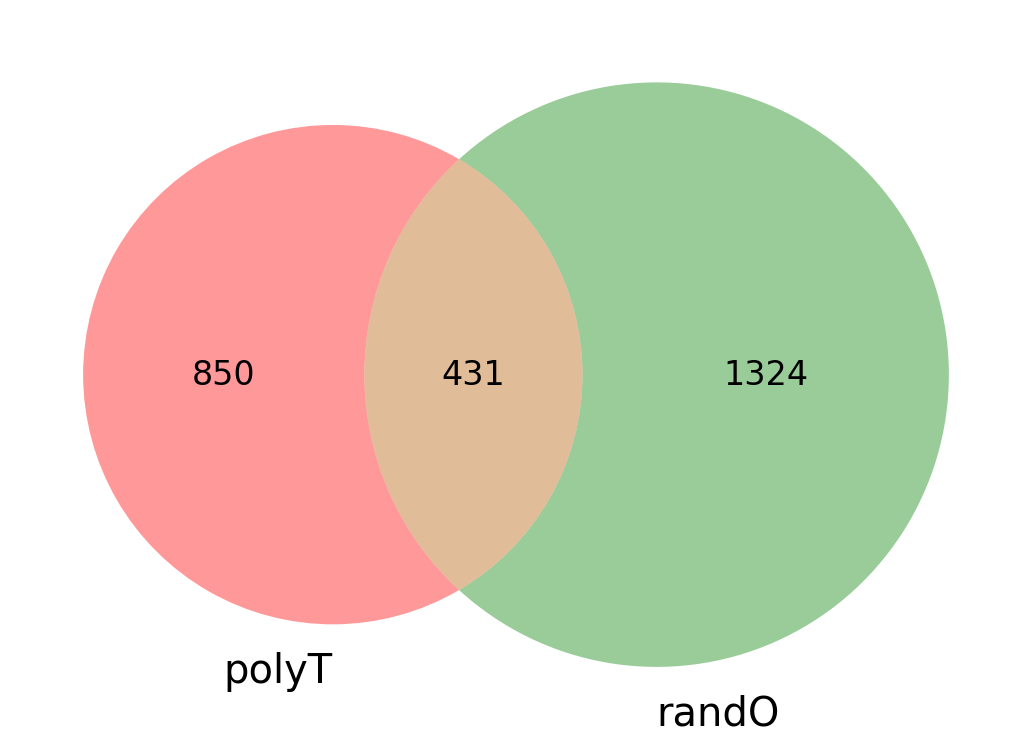

In [ ]:
#!pip install matplotlib-venn
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

aadata = [t for t in adata.obs.index]
iadata = [t for t in Iadata.obs.index]

venn2((set(aadata), set(iadata)), ('polyT', 'merged'))

Finally, we plot the Spearman gene-level correlations between the matched nuclei in

In [ ]:
intersect_g = [gene for gene in adata.var.index if gene in Iadata.var.index]
intersectsc = [t for t in adata.obs.index if t in Iadata.obs.index]

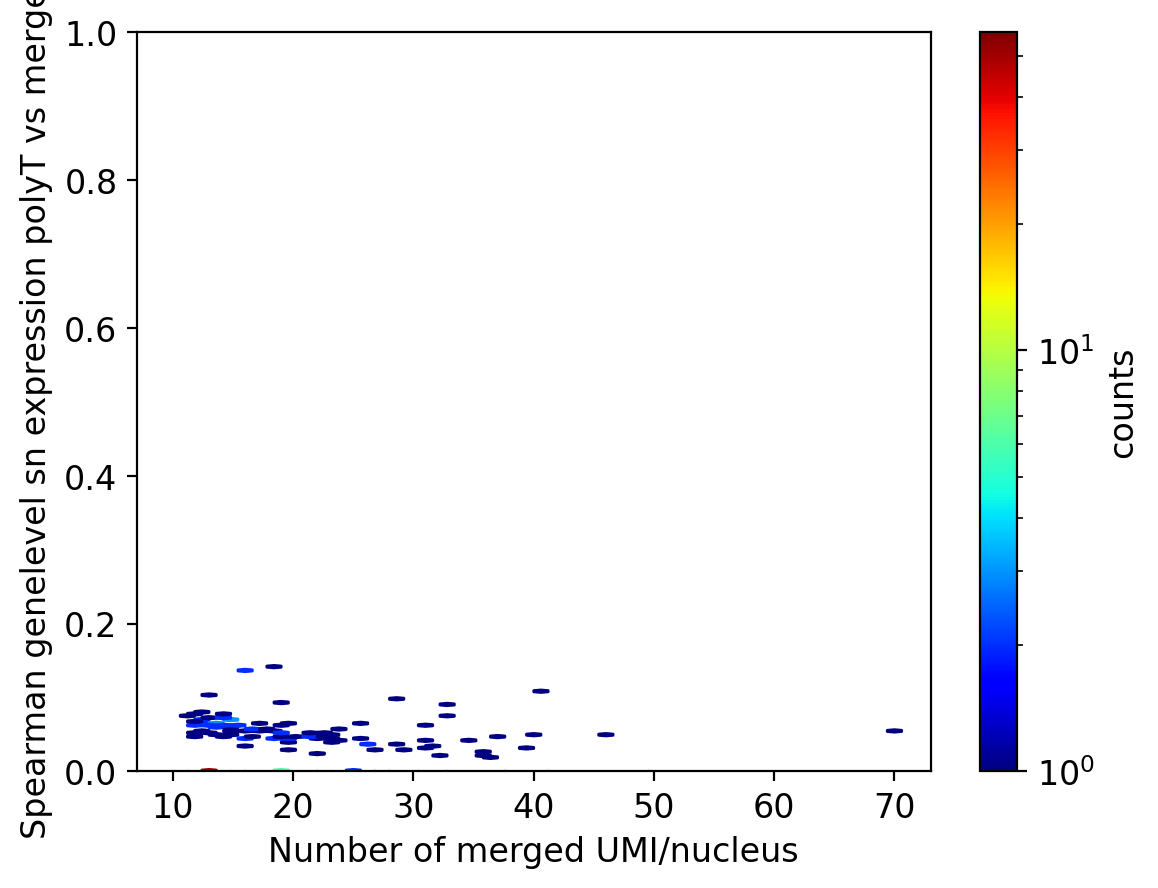

In [ ]:
adata[intersectsc, intersect_g]
spearman_gene_ONT_vs_Ill = []
for c in intersectsc:
    if np.squeeze(np.asarray(adata[c, intersect_g].X.todense())).all() != 1:
        spearman=scipy.stats.spearmanr(np.squeeze(np.asarray(adata[c, intersect_g].X.todense())), np.squeeze(np.asarray(Iadata[c, intersect_g].X.todense())))
        spearman_gene_ONT_vs_Ill.append(spearman[0])

#plt.scatter(adata.obs['n_counts'], spearman_gene_ONT_vs_Ill)
plt.hexbin(adata[intersectsc, intersect_g].obs['n_counts'], spearman_gene_ONT_vs_Ill, gridsize=50, cmap='jet', bins='log')
plt.ylabel("Spearman genelevel sn expression polyT vs merged")
plt.xlabel("Number of merged UMI/nucleus")
plt.ylim((0,1))
plt.colorbar(label='counts')
plt.show()

Finally, we show how to install lr-kallisto from source

In [ ]:
%%time
!git clone https://github.com/pachterlab/kallisto.git
!ls kallisto
!mkdir kallisto/build
!ls kallisto
!ls kallisto/ext/htslib/
!cd kallisto/ext/htslib; autoheader; autoconf
!cd kallisto/build; cmake .. -DMAX_KMER_SIZE=64 -; make

Cloning into 'kallisto'...
remote: Enumerating objects: 8710, done.
remote: Counting objects: 100% (1792/1792), done.
remote: Compressing objects: 100% (524/524), done.
remote: Total 8710 (delta 1337), reused 1578 (delta 1266), pack-reused 6918 (from 1)
Receiving objects: 100% (8710/8710), 9.37 MiB | 12.13 MiB/s, done.
Resolving deltas: 100% (5763/5763), done.
astyle.txt	ext	    gen_release.sh  INSTALL.md	 README.md  test
CMakeLists.txt	func_tests  gulpfile.js     license.txt  src	    unit_tests
astyle.txt  CMakeLists.txt  func_tests	    gulpfile.js  license.txt  src   unit_tests
build	    ext		    gen_release.sh  INSTALL.md	 README.md    test
bcf_sr_sort.c  hfile_gcs.c	 htslib.pc.in	 plugin.c	      tbx.c
bcf_sr_sort.h  hfile_internal.h  htslib_vars.mk  probaln.c	      test
bgzf.c	       hfile_libcurl.c	 INSTALL	 README		      textutils.c
bgzip.c        hfile_net.c	 kfunc.c	 README.md	      thread_pool.c
config.mk.in   hfile_s3.c	 knetfile.c	 realn.c	      thread_pool_internal.h
config